<a href="https://colab.research.google.com/github/ujju2020/ujju2020/blob/main/enhanced_expense_tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enhanced Personal Expense Tracker

A comprehensive expense tracking system with categories, budgets, reporting, and data analysis features.

## Features:
- ✅ Add, edit, delete expenses
- ✅ Categorized expense management
- ✅ Monthly budget tracking
- ✅ Data visualization with charts
- ✅ Monthly/yearly reports
- ✅ CSV import/export
- ✅ Data persistence
- ✅ Input validation

## Ready for Google Colab! 🚀
## Currency: Indian Rupees (₹)

In [1]:
# Import required libraries
import csv
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from collections import defaultdict
import re
import os
from typing import Dict, List, Optional
import warnings
warnings.filterwarnings('ignore')

# Set plot style for better visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("📊 Enhanced Personal Expense Tracker Loaded!")
print("💱 Currency: Indian Rupees (₹)")
print("==" * 25)

📊 Enhanced Personal Expense Tracker Loaded!
💱 Currency: Indian Rupees (₹)


In [2]:
class ExpenseTracker:
    """Enhanced Expense Tracker with advanced features"""

    def __init__(self):
        self.expenses = []
        self.budgets = {}  # category: monthly_budget
        self.categories = [
            'Food & Dining', 'Transportation', 'Shopping', 'Entertainment',
            'Bills & Utilities', 'Healthcare', 'Education', 'Travel', 'Miscellaneous'
        ]
        self.load_data()

    def validate_date(self, date_str: str) -> bool:
        """Validate date format YYYY-MM-DD"""
        try:
            datetime.strptime(date_str, '%Y-%m-%d')
            return True
        except ValueError:
            return False

    def validate_amount(self, amount: str) -> float:
        """Validate and convert amount to float"""
        try:
            amt = float(amount)
            if amt <= 0:
                raise ValueError("Amount must be positive")
            return round(amt, 2)
        except ValueError:
            raise ValueError("Invalid amount format")

    def add_expense(self, date: str, category: str, amount: float, description: str) -> bool:
        """Add a new expense with validation"""
        try:
            # Validate inputs
            if not self.validate_date(date):
                print("❌ Invalid date format. Use YYYY-MM-DD")
                return False

            if category not in self.categories:
                print(f"❌ Invalid category. Choose from: {', '.join(self.categories)}")
                return False

            validated_amount = self.validate_amount(str(amount))

            expense = {
                'id': len(self.expenses) + 1,
                'date': date,
                'category': category,
                'amount': validated_amount,
                'description': description.strip(),
                'created_at': datetime.now().isoformat()
            }

            self.expenses.append(expense)
            self.save_data()
            print(f"✅ Expense added: ₹{validated_amount:.2f} for {category}")
            return True

        except Exception as e:
            print(f"❌ Error adding expense: {e}")
            return False

    def edit_expense(self, expense_id: int, **kwargs) -> bool:
        """Edit an existing expense"""
        try:
            expense = next((e for e in self.expenses if e['id'] == expense_id), None)
            if not expense:
                print(f"❌ Expense with ID {expense_id} not found")
                return False

            # Update fields if provided
            for key, value in kwargs.items():
                if key in expense and value is not None:
                    if key == 'date' and not self.validate_date(value):
                        print("❌ Invalid date format")
                        return False
                    elif key == 'amount':
                        value = self.validate_amount(str(value))
                    elif key == 'category' and value not in self.categories:
                        print("❌ Invalid category")
                        return False
                    expense[key] = value

            self.save_data()
            print(f"✅ Expense {expense_id} updated successfully")
            return True

        except Exception as e:
            print(f"❌ Error editing expense: {e}")
            return False

    def delete_expense(self, expense_id: int) -> bool:
        """Delete an expense"""
        try:
            expense = next((e for e in self.expenses if e['id'] == expense_id), None)
            if not expense:
                print(f"❌ Expense with ID {expense_id} not found")
                return False

            self.expenses.remove(expense)
            self.save_data()
            print(f"✅ Expense {expense_id} deleted successfully")
            return True

        except Exception as e:
            print(f"❌ Error deleting expense: {e}")
            return False

    def set_budget(self, category: str, amount: float) -> bool:
        """Set monthly budget for a category"""
        try:
            if category not in self.categories:
                print(f"❌ Invalid category. Choose from: {', '.join(self.categories)}")
                return False

            validated_amount = self.validate_amount(str(amount))
            self.budgets[category] = validated_amount
            self.save_data()
            print(f"✅ Budget set: ₹{validated_amount:.2f} for {category}")
            return True

        except Exception as e:
            print(f"❌ Error setting budget: {e}")
            return False

    def get_monthly_spending(self, year: int, month: int, category: str = None) -> float:
        """Get total spending for a specific month"""
        total = 0
        for expense in self.expenses:
            expense_date = datetime.strptime(expense['date'], '%Y-%m-%d')
            if expense_date.year == year and expense_date.month == month:
                if category is None or expense['category'] == category:
                    total += expense['amount']
        return total

    def save_data(self):
        """Save expenses and budgets to JSON file"""
        try:
            data = {
                'expenses': self.expenses,
                'budgets': self.budgets,
                'categories': self.categories,
                'currency': 'INR',
                'last_updated': datetime.now().isoformat()
            }
            with open('expense_data.json', 'w') as f:
                json.dump(data, f, indent=2)
        except Exception as e:
            print(f"Warning: Could not save data - {e}")

    def load_data(self):
        """Load expenses and budgets from JSON file"""
        try:
            if os.path.exists('expense_data.json'):
                with open('expense_data.json', 'r') as f:
                    data = json.load(f)
                    self.expenses = data.get('expenses', [])
                    self.budgets = data.get('budgets', {})
                    if 'categories' in data:
                        self.categories = data['categories']
                print(f"📂 Loaded {len(self.expenses)} expenses and {len(self.budgets)} budgets")
        except Exception as e:
            print(f"Warning: Could not load data - {e}")

# Initialize the expense tracker
tracker = ExpenseTracker()
print("✅ Expense Tracker initialized!")

✅ Expense Tracker initialized!


In [3]:
def display_categories():
    """Display available categories"""
    print("\n📂 Available Categories:")
    for i, category in enumerate(tracker.categories, 1):
        print(f"{i:2}. {category}")
    print()

def interactive_add_expense():
    """Interactive function to add expense"""
    print("\n💰 Add New Expense")
    print("=" * 20)

    try:
        # Get date
        date = input("Enter date (YYYY-MM-DD) or press Enter for today: ").strip()
        if not date:
            date = datetime.now().strftime('%Y-%m-%d')

        # Show categories
        display_categories()

        # Get category
        while True:
            try:
                cat_choice = int(input("Select category (number): ")) - 1
                if 0 <= cat_choice < len(tracker.categories):
                    category = tracker.categories[cat_choice]
                    break
                else:
                    print("❌ Invalid choice. Please try again.")
            except ValueError:
                print("❌ Please enter a valid number.")

        # Get amount
        amount = float(input("Enter amount (₹): "))

        # Get description
        description = input("Enter description: ").strip()
        if not description:
            description = f"{category} expense"

        # Add expense
        tracker.add_expense(date, category, amount, description)

    except KeyboardInterrupt:
        print("\n❌ Operation cancelled.")
    except Exception as e:
        print(f"❌ Error: {e}")

def view_expenses(limit: int = 10):
    """View recent expenses"""
    print(f"\n📊 Recent Expenses (Last {limit})")
    print("=" * 50)

    if not tracker.expenses:
        print("No expenses recorded yet.")
        return

    # Sort by date (most recent first)
    sorted_expenses = sorted(tracker.expenses, key=lambda x: x['date'], reverse=True)

    for expense in sorted_expenses[:limit]:
        print(f"ID: {expense['id']:3} | {expense['date']} | {expense['category']:15} | "
              f"₹{expense['amount']:8.2f} | {expense['description'][:30]}")

    total = sum(e['amount'] for e in tracker.expenses)
    print(f"\n💰 Total Expenses: ₹{total:,.2f}")

def interactive_set_budget():
    """Interactive function to set budget"""
    print("\n🎯 Set Monthly Budget")
    print("=" * 22)

    try:
        display_categories()

        # Get category
        while True:
            try:
                cat_choice = int(input("Select category (number): ")) - 1
                if 0 <= cat_choice < len(tracker.categories):
                    category = tracker.categories[cat_choice]
                    break
                else:
                    print("❌ Invalid choice. Please try again.")
            except ValueError:
                print("❌ Please enter a valid number.")

        # Get budget amount
        amount = float(input(f"Enter monthly budget for {category} (₹): "))

        # Set budget
        tracker.set_budget(category, amount)

    except KeyboardInterrupt:
        print("\n❌ Operation cancelled.")
    except Exception as e:
        print(f"❌ Error: {e}")

print("🔧 Helper functions loaded!")

🔧 Helper functions loaded!


In [4]:
def generate_monthly_report(year: int, month: int):
    """Generate comprehensive monthly report"""
    month_names = ['', 'January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']

    print(f"\n📈 Monthly Report: {month_names[month]} {year}")
    print("=" * 50)

    # Filter expenses for the month
    monthly_expenses = []
    for expense in tracker.expenses:
        expense_date = datetime.strptime(expense['date'], '%Y-%m-%d')
        if expense_date.year == year and expense_date.month == month:
            monthly_expenses.append(expense)

    if not monthly_expenses:
        print("No expenses recorded for this month.")
        return

    # Calculate category totals
    category_totals = defaultdict(float)
    for expense in monthly_expenses:
        category_totals[expense['category']] += expense['amount']

    total_spent = sum(category_totals.values())

    print(f"Total Expenses: ₹{total_spent:,.2f}")
    print(f"Number of Transactions: {len(monthly_expenses)}")
    print(f"Average Transaction: ₹{total_spent/len(monthly_expenses):.2f}")
    print("\nCategory Breakdown:")
    print("-" * 30)

    for category, amount in sorted(category_totals.items(), key=lambda x: x[1], reverse=True):
        percentage = (amount / total_spent) * 100
        budget_status = ""
        if category in tracker.budgets:
            budget = tracker.budgets[category]
            if amount > budget:
                budget_status = f" ⚠️ Over budget by ₹{amount - budget:.2f}"
            else:
                budget_status = f" ✅ Under budget (₹{budget - amount:.2f} left)"

        print(f"{category:15} ₹{amount:8.2f} ({percentage:5.1f}%){budget_status}")

def create_expense_charts():
    """Create visualization charts for expenses"""
    if not tracker.expenses:
        print("No expenses to visualize.")
        return

    # Convert to DataFrame for easier plotting
    df = pd.DataFrame(tracker.expenses)
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.to_period('M')

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Expense Analysis Dashboard (₹)', fontsize=16, fontweight='bold')

    # 1. Category wise spending (Pie chart)
    category_totals = df.groupby('category')['amount'].sum().sort_values(ascending=False)
    axes[0,0].pie(category_totals.values, labels=category_totals.index, autopct='%1.1f%%', startangle=90)
    axes[0,0].set_title('Spending by Category')

    # 2. Monthly spending trend (Line chart)
    monthly_totals = df.groupby('month')['amount'].sum()
    axes[0,1].plot(monthly_totals.index.astype(str), monthly_totals.values, marker='o', linewidth=2)
    axes[0,1].set_title('Monthly Spending Trend')
    axes[0,1].set_xlabel('Month')
    axes[0,1].set_ylabel('Amount (₹)')
    axes[0,1].tick_params(axis='x', rotation=45)

    # 3. Category wise spending (Bar chart)
    category_totals.plot(kind='bar', ax=axes[1,0], color='skyblue')
    axes[1,0].set_title('Spending by Category (Bar Chart)')
    axes[1,0].set_xlabel('Category')
    axes[1,0].set_ylabel('Amount (₹)')
    axes[1,0].tick_params(axis='x', rotation=45)

    # 4. Daily spending pattern
    daily_totals = df.groupby(df['date'].dt.date)['amount'].sum()
    axes[1,1].scatter(daily_totals.index, daily_totals.values, alpha=0.6, color='coral')
    axes[1,1].set_title('Daily Spending Pattern')
    axes[1,1].set_xlabel('Date')
    axes[1,1].set_ylabel('Amount (₹)')
    axes[1,1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

def budget_analysis():
    """Analyze budget vs actual spending"""
    if not tracker.budgets:
        print("❌ No budgets set. Use option 4 to set budgets first.")
        return

    current_month = datetime.now().month
    current_year = datetime.now().year

    print(f"\n🎯 Budget Analysis for {datetime.now().strftime('%B %Y')}")
    print("=" * 50)

    total_budget = sum(tracker.budgets.values())
    total_spent = 0

    for category, budget in tracker.budgets.items():
        spent = tracker.get_monthly_spending(current_year, current_month, category)
        total_spent += spent
        remaining = budget - spent
        percentage = (spent / budget) * 100 if budget > 0 else 0

        status = "✅" if remaining >= 0 else "⚠️"
        print(f"{status} {category:15} Budget: ₹{budget:8.2f} | Spent: ₹{spent:8.2f} | "
              f"Remaining: ₹{remaining:8.2f} ({percentage:.1f}%)")

    print("-" * 50)
    total_remaining = total_budget - total_spent
    total_percentage = (total_spent / total_budget) * 100 if total_budget > 0 else 0

    print(f"📊 TOTAL:           Budget: ₹{total_budget:8.2f} | Spent: ₹{total_spent:8.2f} | "
          f"Remaining: ₹{total_remaining:8.2f} ({total_percentage:.1f}%)")

print("📊 Reporting functions loaded!")

📊 Reporting functions loaded!


In [7]:
def export_to_csv(filename: str = 'expenses_export.csv'):
    """Export expenses to CSV file"""
    try:
        if not tracker.expenses:
            print("❌ No expenses to export.")
            return

        with open(filename, 'w', newline='', encoding='utf-8') as csvfile:
            fieldnames = ['id', 'date', 'category', 'amount', 'description', 'created_at']
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            for expense in tracker.expenses:
                writer.writerow(expense)

        print(f"✅ Expenses exported to {filename}")
        print(f"📊 Exported {len(tracker.expenses)} expenses")

    except Exception as e:
        print(f"❌ Error exporting to CSV: {e}")

def import_from_csv(filename: str):
    """Import expenses from CSV file"""
    try:
        if not os.path.exists(filename):
            print(f"❌ File {filename} not found.")
            return

        imported = 0
        with open(filename, 'r', encoding='utf-8') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                try:
                    # Convert amount to float
                    amount = float(row['amount'])

                    # Validate category
                    category = row['category']
                    if category not in tracker.categories:
                        print(f"⚠️ Unknown category '{category}', adding to available categories")
                        tracker.categories.append(category)

                    # Add expense
                    if tracker.add_expense(row['date'], category, amount, row['description']):
                        imported += 1

                except Exception as e:
                    print(f"⚠️ Skipped invalid row: {e}")

        print(f"✅ Imported {imported} expenses from {filename}")

    except Exception as e:
        print(f"❌ Error importing from CSV: {e}")

def search_expenses(query: str = None, category: str = None, date_from: str = None, date_to: str = None):
    """Search expenses with various filters"""
    filtered_expenses = tracker.expenses.copy()

    # Filter by query (description)
    if query:
        filtered_expenses = [e for e in filtered_expenses
                           if query.lower() in e['description'].lower()]

    # Filter by category
    if category:
        filtered_expenses = [e for e in filtered_expenses
                           if e['category'] == category]

    # Filter by date range
    if date_from:
        filtered_expenses = [e for e in filtered_expenses
                           if e['date'] >= date_from]

    if date_to:
        filtered_expenses = [e for e in filtered_expenses
                           if e['date'] <= date_to]

    print(f"\n🔍 Search Results ({len(filtered_expenses)} found)")
    print("=" * 50)

    if not filtered_expenses:
        print("No expenses match your search criteria.")
        return

    for expense in sorted(filtered_expenses, key=lambda x: x['date'], reverse=True):
        print(f"ID: {expense['id']:3} | {expense['date']} | {expense['category']:15} | "
              f"₹{expense['amount']:8.2f} | {expense['description'][:40]}")

    total = sum(e['amount'] for e in filtered_expenses)
    print(f"\n💰 Total: ₹{total:,.2f}")

print("📁 Import/Export functions loaded!")

📁 Import/Export functions loaded!


In [8]:
def display_main_menu():
    """Display the main menu"""
    print("\n" + "=" * 60)
    print("💰 ENHANCED PERSONAL EXPENSE TRACKER (₹)")
    print("=" * 60)
    print("1.  💳 Add New Expense")
    print("2.  📊 View Recent Expenses")
    print("3.  ✏️  Edit Expense")
    print("4.  🗑️  Delete Expense")
    print("5.  🎯 Set Budget")
    print("6.  📈 Monthly Report")
    print("7.  📊 Budget Analysis")
    print("8.  📉 View Charts")
    print("9.  🔍 Search Expenses")
    print("10. 📁 Export to CSV")
    print("11. 📂 Import from CSV")
    print("12. 💾 Save & Exit")
    print("=" * 60)

def main_menu():
    """Main interactive menu"""
    while True:
        try:
            display_main_menu()
            choice = input("\n🎯 Enter your choice (1-12): ").strip()

            if choice == '1':
                interactive_add_expense()

            elif choice == '2':
                try:
                    limit = int(input("Enter number of recent expenses to show (default 10): ") or "10")
                    view_expenses(limit)
                except ValueError:
                    view_expenses()

            elif choice == '3':
                try:
                    expense_id = int(input("Enter expense ID to edit: "))
                    print("Enter new values (press Enter to keep current value):")

                    date = input("Date (YYYY-MM-DD): ").strip() or None

                    display_categories()
                    cat_input = input("Category number: ").strip()
                    category = None
                    if cat_input:
                        try:
                            cat_choice = int(cat_input) - 1
                            if 0 <= cat_choice < len(tracker.categories):
                                category = tracker.categories[cat_choice]
                        except ValueError:
                            pass

                    amount_input = input("Amount (₹): ").strip()
                    amount = float(amount_input) if amount_input else None

                    description = input("Description: ").strip() or None

                    tracker.edit_expense(expense_id, date=date, category=category,
                                       amount=amount, description=description)
                except ValueError:
                    print("❌ Invalid input.")

            elif choice == '4':
                try:
                    expense_id = int(input("Enter expense ID to delete: "))
                    confirm = input(f"Are you sure you want to delete expense {expense_id}? (y/N): ")
                    if confirm.lower() == 'y':
                        tracker.delete_expense(expense_id)
                except ValueError:
                    print("❌ Invalid expense ID.")

            elif choice == '5':
                interactive_set_budget()

            elif choice == '6':
                try:
                    year = int(input(f"Enter year (default {datetime.now().year}): ") or str(datetime.now().year))
                    month = int(input(f"Enter month (1-12, default {datetime.now().month}): ") or str(datetime.now().month))
                    generate_monthly_report(year, month)
                except ValueError:
                    print("❌ Invalid year or month.")

            elif choice == '7':
                budget_analysis()

            elif choice == '8':
                create_expense_charts()

            elif choice == '9':
                print("\n🔍 Search Options (press Enter to skip):")
                query = input("Search in description: ").strip() or None

                display_categories()
                cat_input = input("Filter by category (number): ").strip()
                category = None
                if cat_input:
                    try:
                        cat_choice = int(cat_input) - 1
                        if 0 <= cat_choice < len(tracker.categories):
                            category = tracker.categories[cat_choice]
                    except ValueError:
                        pass

                date_from = input("From date (YYYY-MM-DD): ").strip() or None
                date_to = input("To date (YYYY-MM-DD): ").strip() or None

                search_expenses(query, category, date_from, date_to)

            elif choice == '10':
                filename = input("Enter filename (default: expenses_export.csv): ").strip()
                if not filename:
                    filename = 'expenses_export.csv'
                export_to_csv(filename)

            elif choice == '11':
                filename = input("Enter CSV filename to import: ").strip()
                if filename:
                    import_from_csv(filename)
                else:
                    print("❌ Please provide a filename.")

            elif choice == '12':
                tracker.save_data()
                print("\n💾 Data saved successfully!")
                print("🙏 धन्यवाद! Thank you for using Enhanced Expense Tracker!")
                break

            else:
                print("❌ Invalid choice. Please select 1-12.")

            input("\n⏸️ Press Enter to continue...")

        except KeyboardInterrupt:
            print("\n\n👋 Goodbye! Don't forget to save your data.")
            break
        except Exception as e:
            print(f"❌ An error occurred: {e}")
            input("⏸️ Press Enter to continue...")

print("🎮 Main menu function loaded!")
print("\nℹ️ Run 'main_menu()' to start the interactive expense tracker!")

🎮 Main menu function loaded!

ℹ️ Run 'main_menu()' to start the interactive expense tracker!


In [9]:
# Quick Start Demo with Indian Rupees
print("🚀 QUICK START DEMO (Indian Rupees)")
print("=" * 35)

# Add some sample expenses if none exist
if len(tracker.expenses) == 0:
    print("📝 Adding sample expenses for demonstration...")

    sample_expenses = [
        ('2024-10-01', 'Food & Dining', 450.50, 'Lunch at restaurant'),
        ('2024-10-02', 'Transportation', 250.00, 'Auto rickshaw fare'),
        ('2024-10-03', 'Shopping', 1200.75, 'Grocery shopping'),
        ('2024-10-04', 'Entertainment', 300.00, 'Movie tickets'),
        ('2024-10-05', 'Bills & Utilities', 1500.00, 'Electricity bill'),
        ('2024-10-06', 'Healthcare', 800.00, 'Doctor consultation'),
        ('2024-10-07', 'Education', 2500.00, 'Course fee'),
        ('2024-10-08', 'Travel', 1800.00, 'Bus ticket to hometown')
    ]

    for date, category, amount, description in sample_expenses:
        tracker.add_expense(date, category, amount, description)

    # Set sample budgets in Indian Rupees
    print("\n🎯 Setting sample budgets...")
    sample_budgets = [
        ('Food & Dining', 5000.00),
        ('Transportation', 2000.00),
        ('Shopping', 8000.00),
        ('Entertainment', 3000.00),
        ('Bills & Utilities', 6000.00),
        ('Healthcare', 4000.00)
    ]

    for category, amount in sample_budgets:
        tracker.set_budget(category, amount)

print(f"\n📊 Current Status:")
print(f"  💰 Total Expenses: {len(tracker.expenses)}")
print(f"  🎯 Budgets Set: {len(tracker.budgets)}")
print(f"  📂 Categories: {len(tracker.categories)}")
print(f"  💱 Currency: Indian Rupees (₹)")

print("\n✅ Ready to use! Here are some quick commands:")
print("  • main_menu() - Start interactive menu")
print("  • view_expenses(5) - View last 5 expenses")
print("  • create_expense_charts() - Generate charts")
print("  • generate_monthly_report(2024, 10) - October 2024 report")
print("  • budget_analysis() - Check budget status")
print("  • tracker.add_expense('2024-10-09', 'Food & Dining', 350, 'Dinner') - Add expense programmatically")

🚀 QUICK START DEMO (Indian Rupees)
📝 Adding sample expenses for demonstration...
✅ Expense added: ₹450.50 for Food & Dining
✅ Expense added: ₹250.00 for Transportation
✅ Expense added: ₹1200.75 for Shopping
✅ Expense added: ₹300.00 for Entertainment
✅ Expense added: ₹1500.00 for Bills & Utilities
✅ Expense added: ₹800.00 for Healthcare
✅ Expense added: ₹2500.00 for Education
✅ Expense added: ₹1800.00 for Travel

🎯 Setting sample budgets...
✅ Budget set: ₹5000.00 for Food & Dining
✅ Budget set: ₹2000.00 for Transportation
✅ Budget set: ₹8000.00 for Shopping
✅ Budget set: ₹3000.00 for Entertainment
✅ Budget set: ₹6000.00 for Bills & Utilities
✅ Budget set: ₹4000.00 for Healthcare

📊 Current Status:
  💰 Total Expenses: 8
  🎯 Budgets Set: 6
  📂 Categories: 9
  💱 Currency: Indian Rupees (₹)

✅ Ready to use! Here are some quick commands:
  • main_menu() - Start interactive menu
  • view_expenses(5) - View last 5 expenses
  • create_expense_charts() - Generate charts
  • generate_monthly_repo

In [10]:
# Quick view of current expenses
view_expenses(5)


📊 Recent Expenses (Last 5)
ID:   8 | 2024-10-08 | Travel          | ₹ 1800.00 | Bus ticket to hometown
ID:   7 | 2024-10-07 | Education       | ₹ 2500.00 | Course fee
ID:   6 | 2024-10-06 | Healthcare      | ₹  800.00 | Doctor consultation
ID:   5 | 2024-10-05 | Bills & Utilities | ₹ 1500.00 | Electricity bill
ID:   4 | 2024-10-04 | Entertainment   | ₹  300.00 | Movie tickets

💰 Total Expenses: ₹8,801.25


In [11]:
# Display current budget status
budget_analysis()


🎯 Budget Analysis for April 2026
✅ Food & Dining   Budget: ₹ 5000.00 | Spent: ₹    0.00 | Remaining: ₹ 5000.00 (0.0%)
✅ Transportation  Budget: ₹ 2000.00 | Spent: ₹    0.00 | Remaining: ₹ 2000.00 (0.0%)
✅ Shopping        Budget: ₹ 8000.00 | Spent: ₹    0.00 | Remaining: ₹ 8000.00 (0.0%)
✅ Entertainment   Budget: ₹ 3000.00 | Spent: ₹    0.00 | Remaining: ₹ 3000.00 (0.0%)
✅ Bills & Utilities Budget: ₹ 6000.00 | Spent: ₹    0.00 | Remaining: ₹ 6000.00 (0.0%)
✅ Healthcare      Budget: ₹ 4000.00 | Spent: ₹    0.00 | Remaining: ₹ 4000.00 (0.0%)
--------------------------------------------------
📊 TOTAL:           Budget: ₹28000.00 | Spent: ₹    0.00 | Remaining: ₹28000.00 (0.0%)


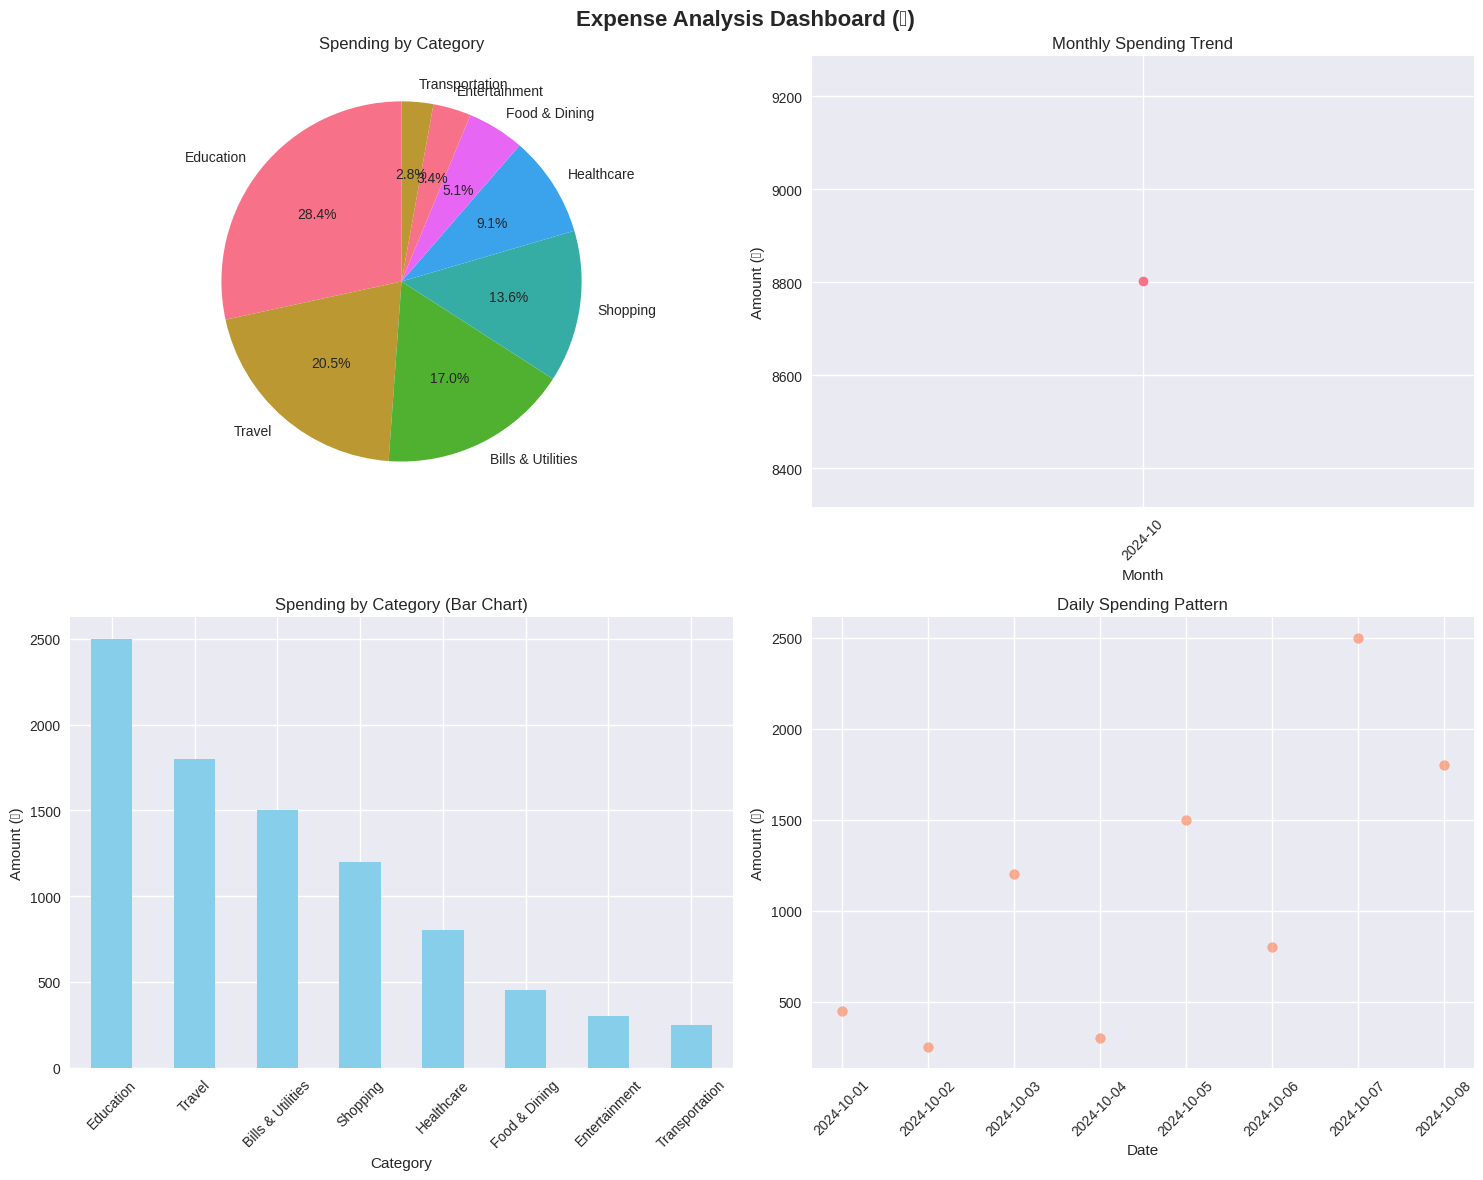

In [12]:
# Generate expense charts
create_expense_charts()

In [13]:
# Start the interactive menu (uncomment to run)
# main_menu()

print("\n🎮 To start the interactive menu, run: main_menu()")
print("\n📝 Or use individual functions like:")
print("  • tracker.add_expense('2024-10-09', 'Food & Dining', 350.50, 'Coffee and snacks')")
print("  • generate_monthly_report(2024, 10)")
print("  • export_to_csv('my_expenses.csv')")

print("\n🚀 Enhanced Personal Expense Tracker is ready to use!")
print("💱 All amounts are in Indian Rupees (₹)")
print("🙏 धन्यवाद - Happy expense tracking!")


🎮 To start the interactive menu, run: main_menu()

📝 Or use individual functions like:
  • tracker.add_expense('2024-10-09', 'Food & Dining', 350.50, 'Coffee and snacks')
  • generate_monthly_report(2024, 10)
  • export_to_csv('my_expenses.csv')

🚀 Enhanced Personal Expense Tracker is ready to use!
💱 All amounts are in Indian Rupees (₹)
🙏 धन्यवाद - Happy expense tracking!
